In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [87]:
# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

In [88]:
# Load the dataset
df = pd.read_csv('../data/processed/integrated_all_columns.csv')
df.fillna(0, inplace=True)
# Convert is_gentrified to boolean
df['is_gentrified'] = df['is_gentrified'].astype(bool)

In [89]:
df

,year,zip_code,After Hours - Licensed Est,Animal Waste,Banging/Pounding,Blocked Bike Lane,Blocked Crosswalk,Blocked Hydrant,Blocked Sidewalk,Broken Sidewalk,...,ttl_wellness_center,ttl_wholesaler,ttl_wine_bar,ttl_yoga_studio,EXPENSIVE,INEXPENSIVE,MODERATE,rent,rent_change,is_gentrified
0,2022,10001,9.0,0.0,639.0,255.0,67.0,139.0,85.0,0.0,...,0.0,0.0,8.0,0.0,17.0,25.0,90.0,4870.677598,0.205286,False
1,2022,10002,4.0,0.0,990.0,884.0,224.0,301.0,343.0,0.0,...,0.0,2.0,10.0,0.0,12.0,62.0,75.0,3554.796326,0.244991,True
2,2022,10003,1.0,0.0,410.0,513.0,81.0,140.0,107.0,0.0,...,1.0,1.0,7.0,1.0,25.0,68.0,108.0,3941.807689,0.256503,True
3,2022,10004,0.0,0.0,7.0,16.0,12.0,27.0,57.0,0.0,...,0.0,0.0,1.0,0.0,2.0,13.0,11.0,3946.666521,0.044439,False
4,2022,10005,0.0,0.0,74.0,26.0,10.0,13.0,24.0,0.0,...,0.0,0.0,1.0,0.0,4.0,1.0,5.0,4275.182475,0.217989,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,2023,11432,0.0,0.0,596.0,1.0,82.0,287.0,187.0,0.0,...,0.0,0.0,0.0,0.0,0.0,12.0,2.0,2309.792636,-0.242789,False
275,2023,11434,0.0,0.0,307.0,0.0,47.0,401.0,171.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.0,4.0,3135.304935,0.247586,True
276,2023,11435,0.0,0.0,530.0,2.0,160.0,828.0,304.0,0.0,...,0.0,0.0,0.0,0.0,0.0,7.0,3.0,1954.208071,-0.262071,False
277,2023,11691,0.0,0.0,821.0,30.0,74.0,273.0,159.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,1.0,2271.818549,0.214189,False


In [90]:
from sklearn.model_selection import train_test_split

features = df.drop(columns=['is_gentrified','rent','rent_change','year','zip_code','merge_key','N/A'])  
target = df['is_gentrified']                   

X_train, X_test, y_train, y_test = train_test_split(
    features,                    
    target,                      
    test_size=0.2, 
    random_state=42, 
    stratify=target              
)


In [91]:
X_train

,After Hours - Licensed Est,Animal Waste,Banging/Pounding,Blocked Bike Lane,Blocked Crosswalk,Blocked Hydrant,Blocked Sidewalk,Broken Sidewalk,Building,Business not in compliance,...,ttl_video_arcade,ttl_vietnamese_restaurant,ttl_wedding_venue,ttl_wellness_center,ttl_wholesaler,ttl_wine_bar,ttl_yoga_studio,EXPENSIVE,INEXPENSIVE,MODERATE
232,3.0,0.0,431.0,28.0,246.0,1827.0,678.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,28.0
90,2.0,0.0,477.0,96.0,135.0,874.0,171.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,14.0,14.0
122,0.0,0.0,242.0,5.0,72.0,1184.0,89.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
59,0.0,0.0,641.0,46.0,43.0,220.0,89.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,3.0
78,1.0,0.0,402.0,1.0,276.0,2806.0,333.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,19.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,1.0,0.0,455.0,10.0,69.0,776.0,173.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,5.0
11,3.0,0.0,254.0,147.0,81.0,164.0,150.0,0.0,0.0,0.0,...,0.0,5.0,1.0,0.0,1.0,13.0,0.0,27.0,64.0,94.0
12,0.0,0.0,140.0,168.0,74.0,74.0,66.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,10.0,0.0,19.0,27.0,77.0
261,0.0,0.0,161.0,6.0,57.0,878.0,140.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0


In [92]:
feature_names = X_train.columns.tolist()

In [93]:
X_train = X_train.values  
X_test = X_test.values
y_train = y_train.values 
y_test = y_test.values

In [94]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [95]:
print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (223, 230)
Test set: (56, 230)


In [96]:
# Function to evaluate model performance
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Train model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Print results
    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['Not Gentrified', 'Gentrified'],
               yticklabels=['Not Gentrified', 'Gentrified'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()
    
    # Return metrics and model for comparison
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }, model


Logistic Regression Performance:
Accuracy: 0.6964
Precision: 0.6333
Recall: 0.7600
F1 Score: 0.6909


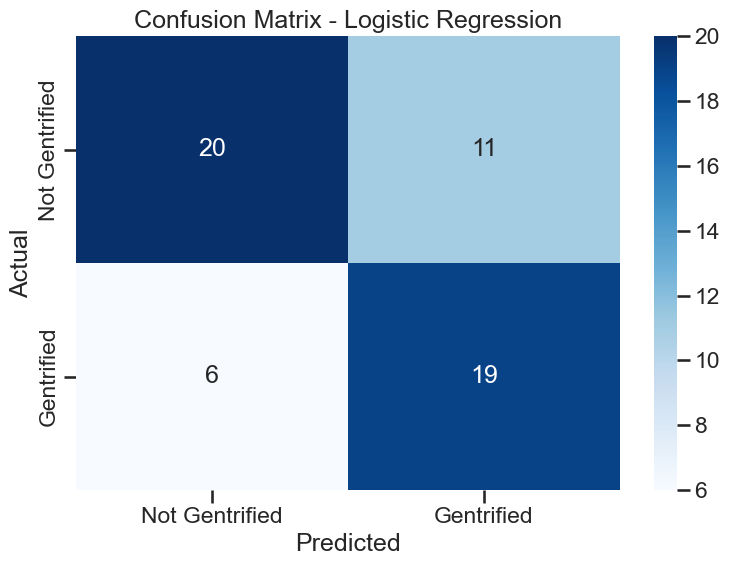


Decision Tree Performance:
Accuracy: 0.7679
Precision: 0.7727
Recall: 0.6800
F1 Score: 0.7234


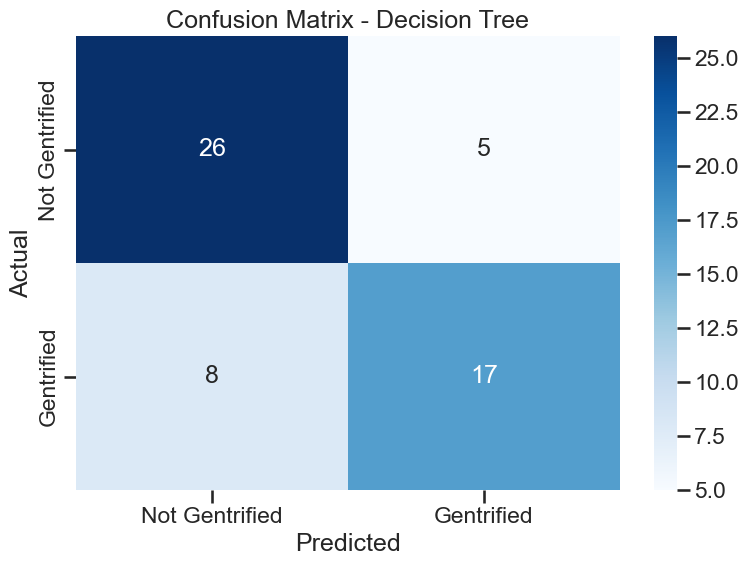


Random Forest Performance:
Accuracy: 0.7679
Precision: 0.8000
Recall: 0.6400
F1 Score: 0.7111


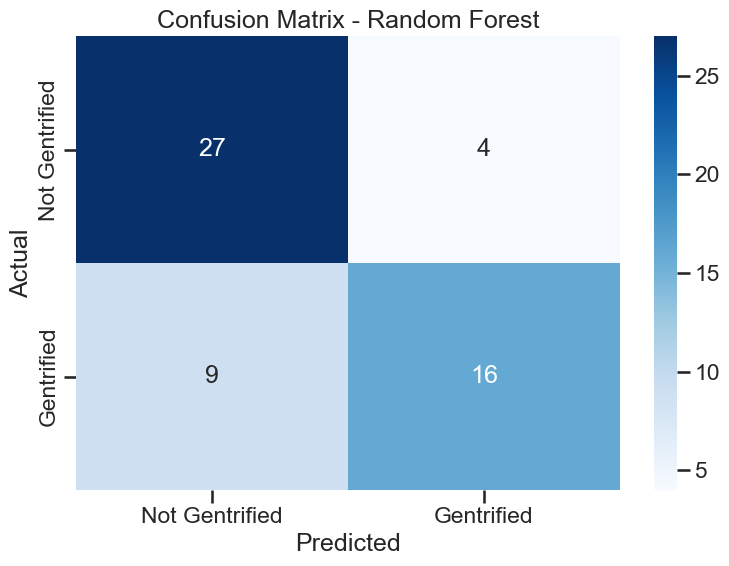


Naive Bayes Performance:
Accuracy: 0.7143
Precision: 0.8462
Recall: 0.4400
F1 Score: 0.5789


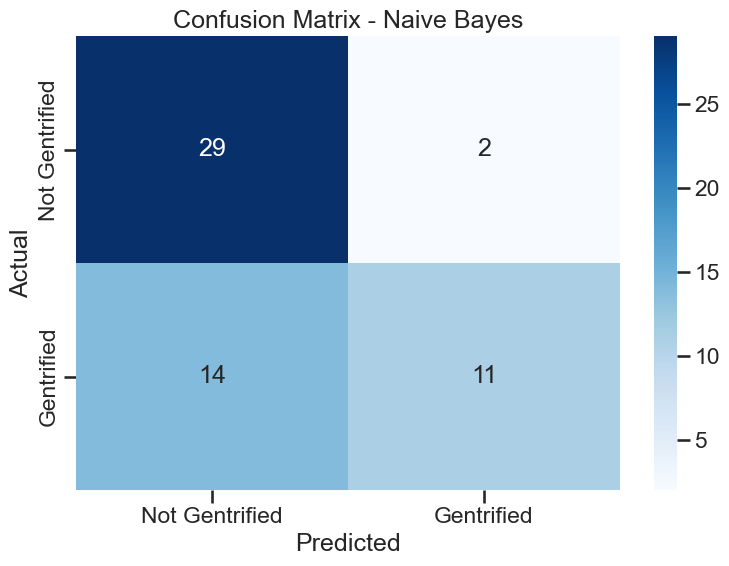

In [97]:
# Create and evaluate models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42),
    'Naive Bayes': GaussianNB()
}

results = {}
trained_models = {}

for name, model in models.items():
    metrics, trained_model = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, name)
    results[name] = metrics
    trained_models[name] = trained_model

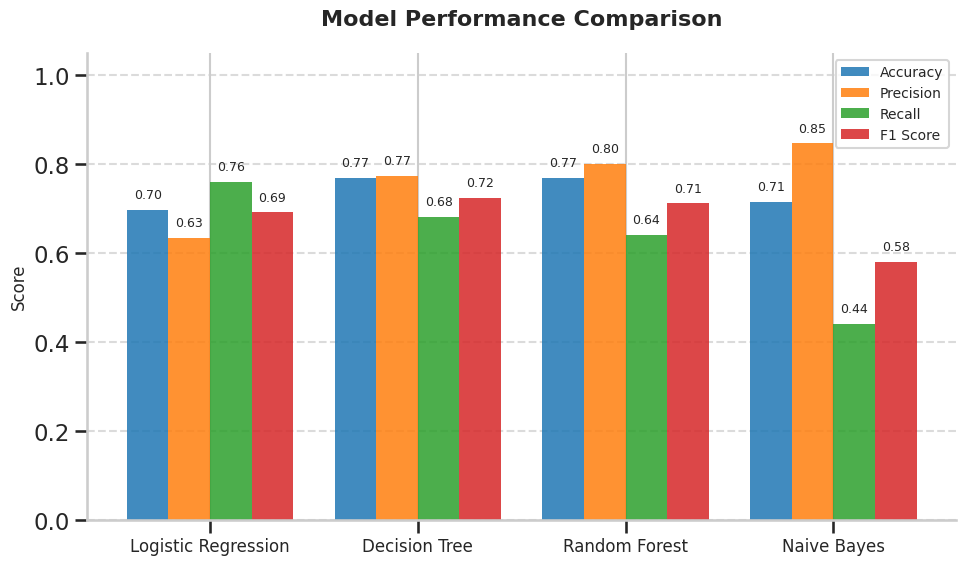

In [98]:
# Compare model performances visually
plt.rcParams['font.family'] = 'DejaVu Sans' 
model_names = list(results.keys())
metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)


x = np.arange(len(model_names))
width = 0.2  

for i, metric in enumerate(metrics):
    values = [results[model][metric] for model in model_names]
    ax.bar(x + i*width, values, width, label=metric_labels[i], alpha=0.85)


ax.set_title('Model Performance Comparison', pad=20, fontsize=16, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.legend(loc='upper right', frameon=True, fontsize=10)

for i, model in enumerate(model_names):
    for j, metric in enumerate(metrics):
        value = results[model][metric]
        ax.text(x[i] + j*width, value + 0.02, f'{value:.2f}', 
                ha='center', va='bottom', fontsize=9)


ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [99]:
from sklearn.inspection import permutation_importance
# Function to extract feature importance from different models
def get_feature_importance(model_name, model, X, y, feature_names):
    try:
        if model_name in ['Random Forest', 'Decision Tree']:
            importances = model.feature_importances_
        elif model_name == 'Logistic Regression':
            importances = np.abs(model.coef_[0])  
        elif model_name == 'Naive Bayes':
            perm_importance = permutation_importance(model, X, y, n_repeats=10, random_state=42)
            importances = perm_importance.importances_mean
        else:
            raise ValueError(f"Unsupported model type: {model_name}")

       
        importances = np.asarray(importances).ravel()  
        
        
        if len(importances) != len(feature_names):
            raise ValueError(
                f"Length mismatch: got {len(importances)} importance scores "
                f"for {len(feature_names)} features"
            )
            
        return pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
    except Exception as e:
        print(f"Error in {model_name}: {str(e)}")
        return pd.DataFrame(columns=['Feature', 'Importance'])

# Get feature importance for each model
importance_by_model = {}

In [100]:
for name, model in trained_models.items():
    print(f"\nExtracting feature importance for {name}...")
    try:
        importance_df = get_feature_importance(
            name, model, X_train_scaled, y_train, feature_names
        )
        importance_by_model[name] = importance_df
        print(f"Top 10 features for {name}:")
        print(importance_df.head(10))
    except Exception as e:
        print(f"Error processing {name}: {str(e)}")


Extracting feature importance for Logistic Regression...
Top 10 features for Logistic Regression:
                           Feature  Importance
58   Posted Parking Sign Violation    1.469416
4                Blocked Crosswalk    1.287143
143                      ttl_diner    1.109056
190              ttl_movie_theater    1.068091
84             less_than_9th_grade    0.986566
163                     ttl_health    0.945237
123          ttl_brunch_restaurant    0.924577
2                 Banging/Pounding    0.863983
87          some_college_no_degree    0.756542
0       After Hours - Licensed Est    0.753036

Extracting feature importance for Decision Tree...
Top 10 features for Decision Tree:
                     Feature  Importance
133          ttl_coffee_shop    0.242516
88         associates_degree    0.146902
48      Paper License Plates    0.128427
86      high_school_graduate    0.106194
82         median_home_value    0.100587
85         9th_to_12th_grade    0.093170
100     pc

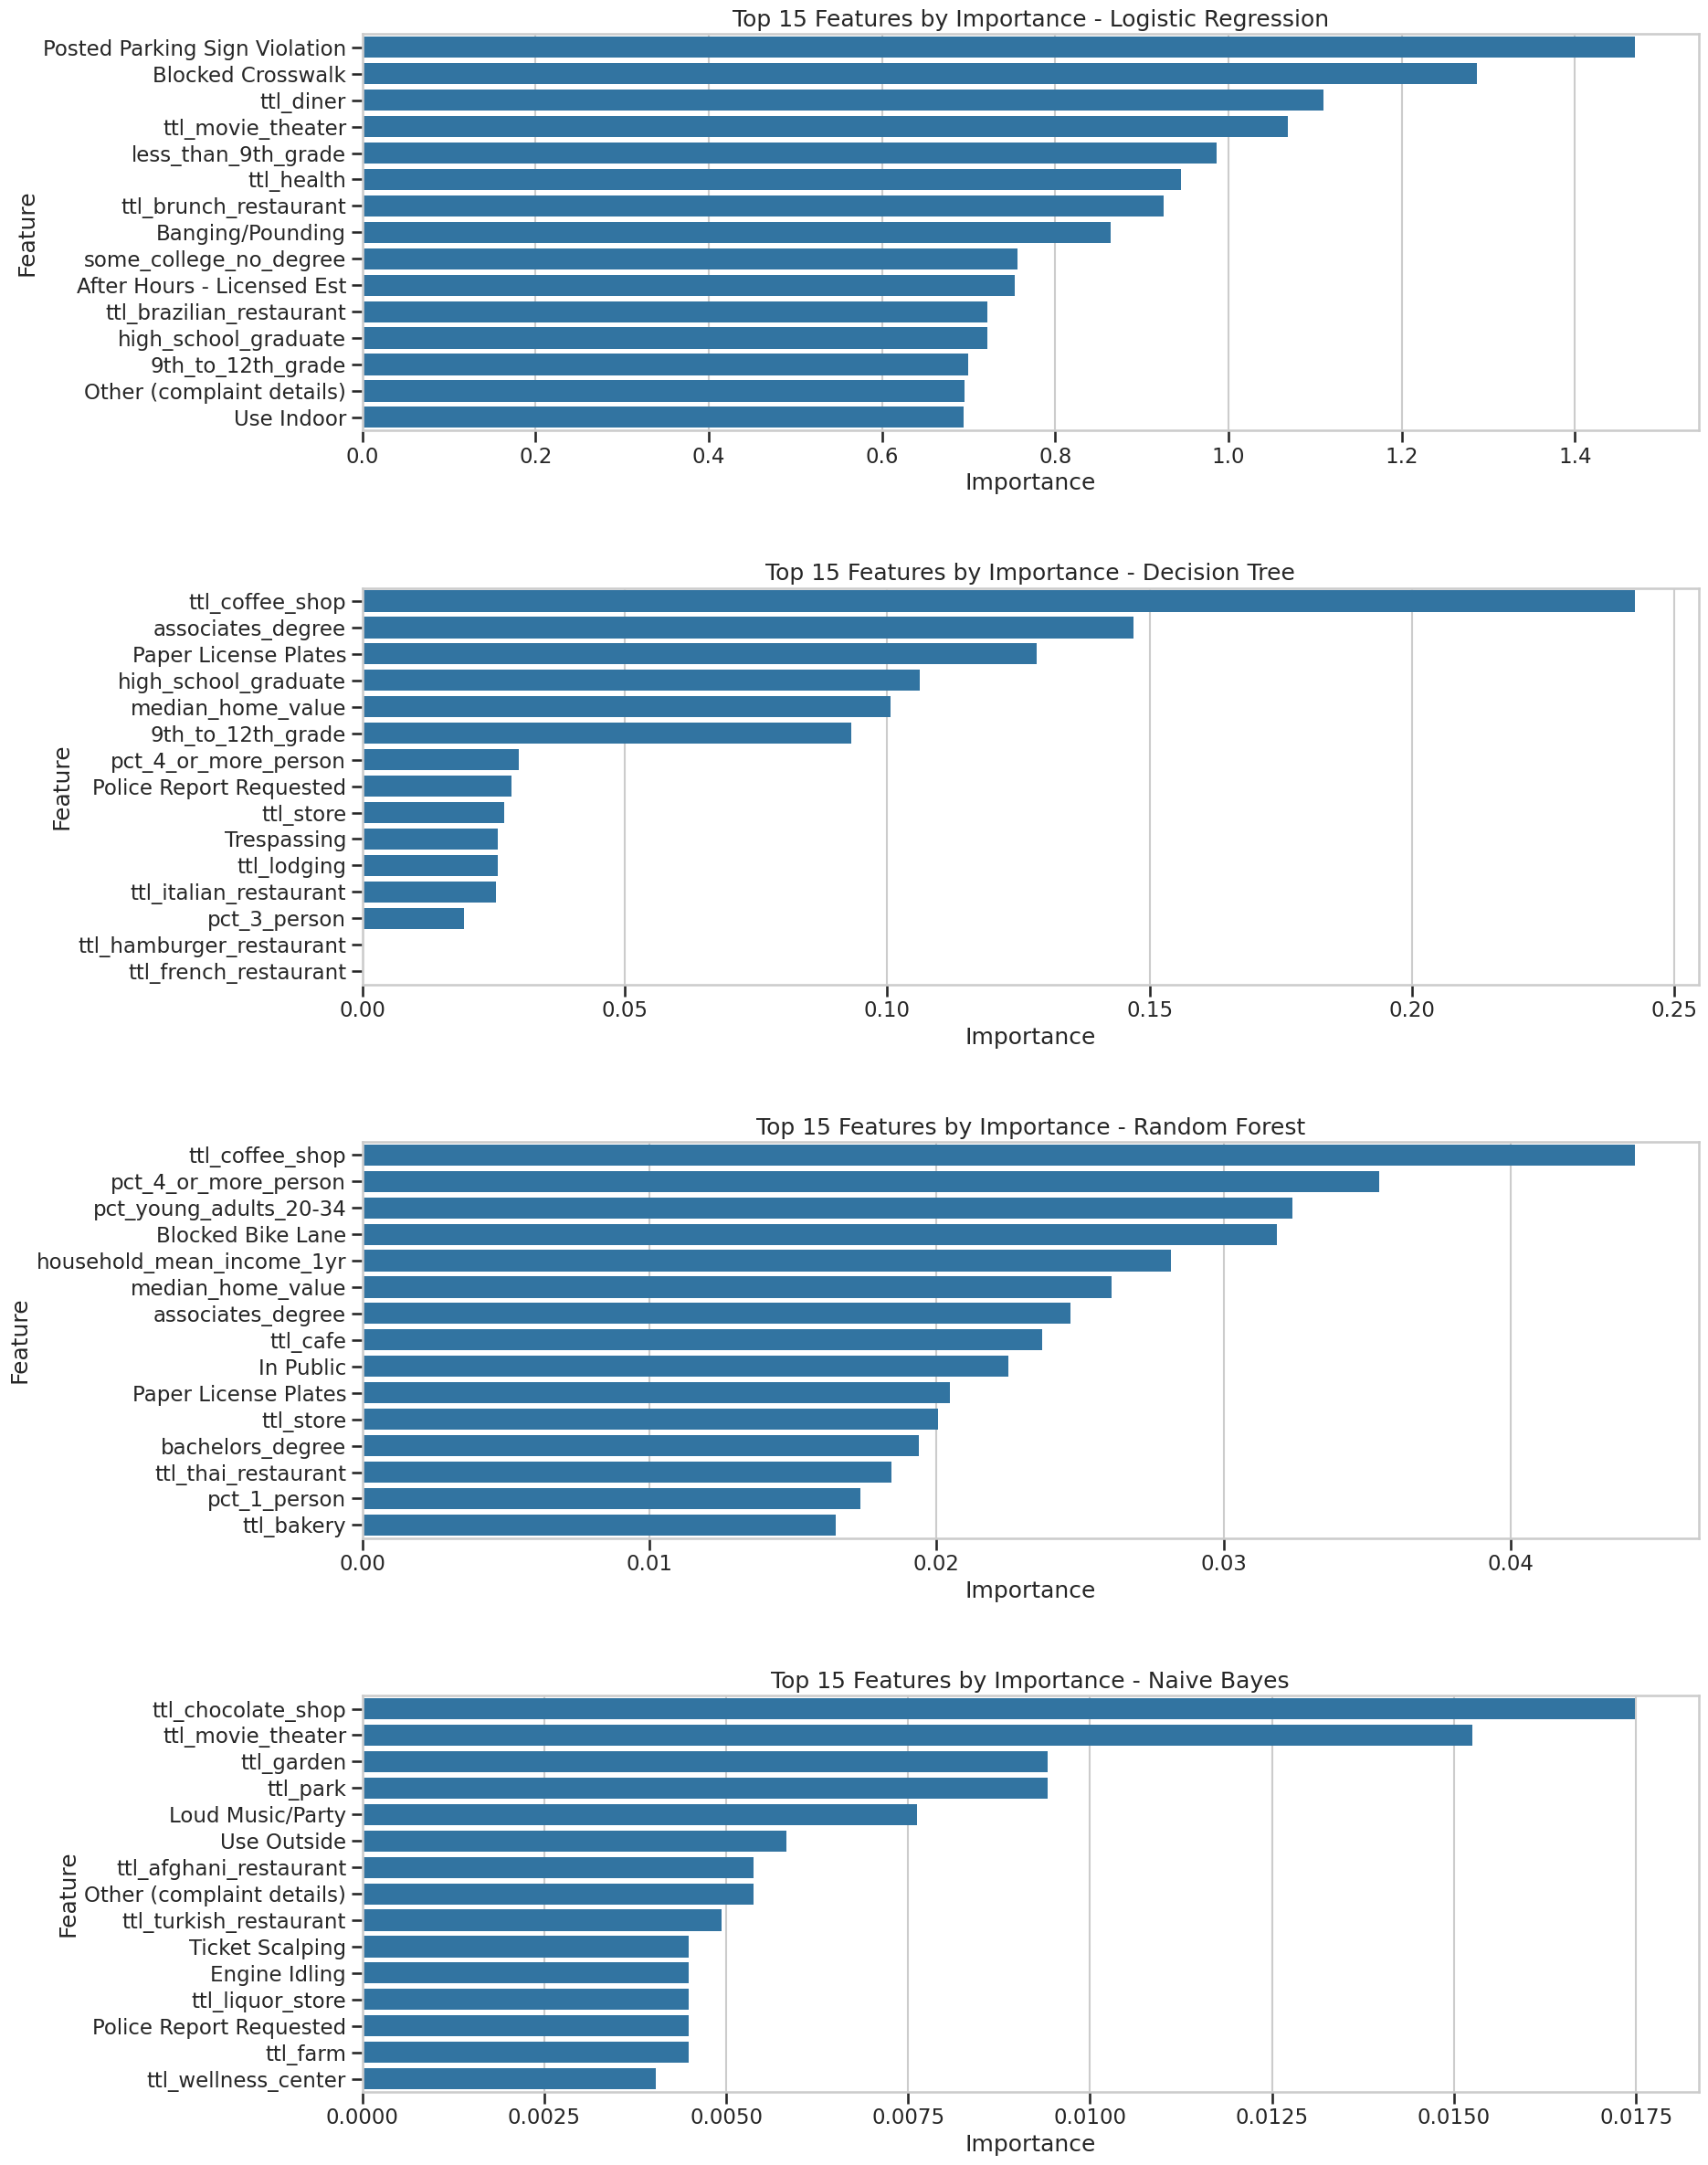

In [101]:
# Visualize feature importance for each model
plt.figure(figsize=(20, 25))

for i, (name, importance_df) in enumerate(importance_by_model.items()):
    plt.subplot(4, 1, i+1)
    
    # Get top 15 features
    top_features = importance_df.head(15)
    
    # Create bar plot
    sns.barplot(x='Importance', y='Feature', data=top_features)
    plt.title(f'Top 15 Features by Importance - {name}')
    plt.tight_layout()

plt.tight_layout(pad=3.0)
plt.show()

In [102]:
# Compare feature rankings across models
# First, get the rankings for each model
rankings = {}

for name, importance_df in importance_by_model.items():
    # Add rank column (1 is highest importance)
    importance_df['Rank'] = importance_df['Importance'].rank(ascending=False)
    # Extract just feature and rank
    rankings[name] = importance_df[['Feature', 'Rank']].set_index('Feature')

# Combine all rankings into one dataframe
all_rankings = pd.concat(rankings, axis=1)

# Find top 20 features that appear in multiple models' top rankings
# Sum the ranks across models (lower sum = more important overall)
all_rankings['Rank_Sum'] = all_rankings.sum(axis=1)
top_consensus_features = all_rankings.sort_values('Rank_Sum').head(20)

print("\nTop 20 consensus features across all models:")
print(top_consensus_features)



Top 20 consensus features across all models:
                           Logistic Regression Decision Tree Random Forest  \
                                          Rank          Rank          Rank   
Feature                                                                      
high_school_graduate                      12.0           4.0          16.0   
Other (complaint details)                 14.0         122.0          46.0   
Trespassing                              121.0          10.0          19.0   
Blocked Crosswalk                          2.0         122.0          27.0   
9th_to_12th_grade                         13.0           6.0          42.0   
household_mean_income_1yr                 55.0         122.0           5.0   
Police Report Requested                   89.0           8.0         105.0   
ttl_grocery_store                         19.0         122.0          58.0   
Loud Music/Party                          80.0         122.0          31.0   
Ticket Scalping   

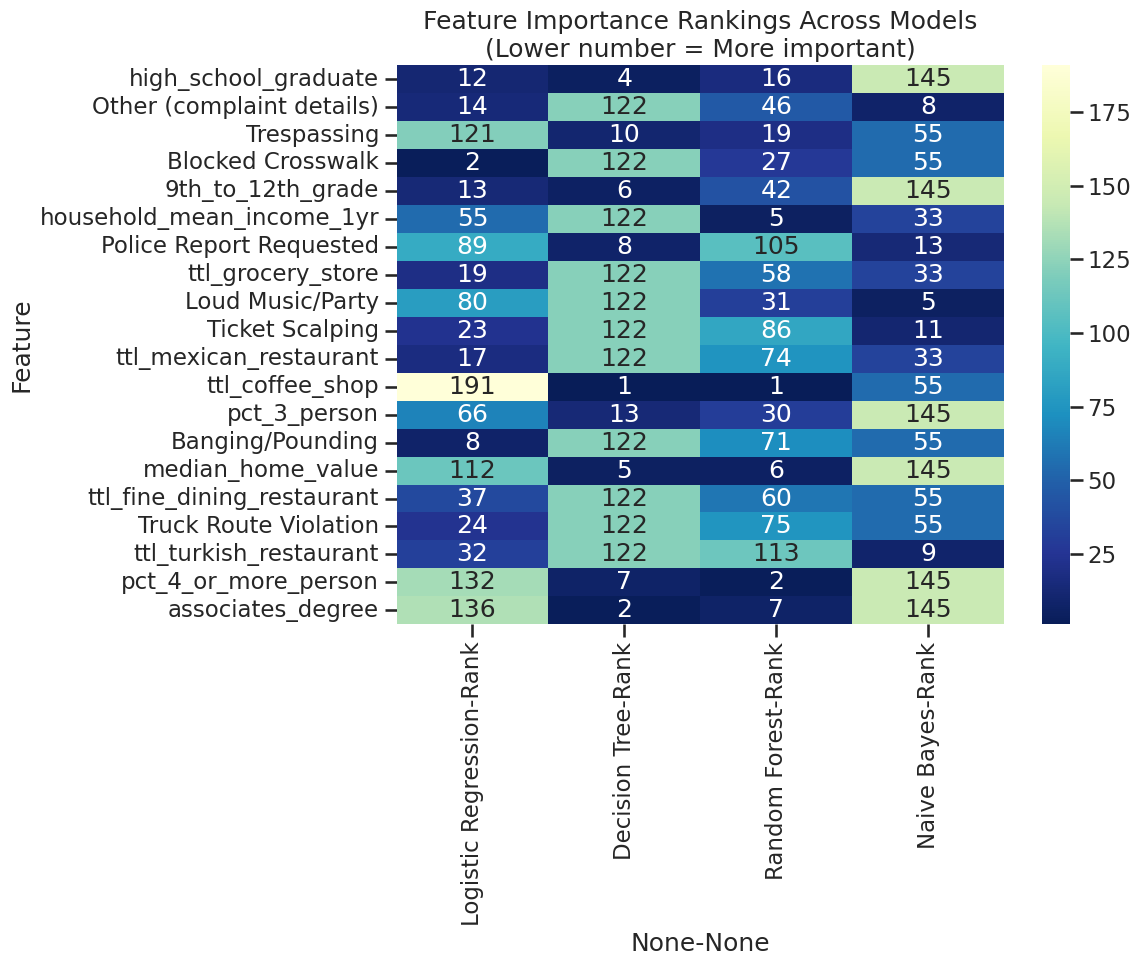

In [103]:
# Visualize consensus ranking
plt.figure(figsize=(12, 10))
sns.heatmap(top_consensus_features.drop('Rank_Sum', axis=1), 
            annot=True, cmap='YlGnBu_r', fmt='.0f')
plt.title('Feature Importance Rankings Across Models\n(Lower number = More important)')
plt.tight_layout()
plt.show()

In [104]:
# Create a visualization showing the top 10 consistent features
# across all models
top_10_consistent = top_consensus_features.head(10).index.tolist()

# Create a dataframe with normalized importance values
normalized_importance = pd.DataFrame(index=top_10_consistent)

for name, importance_df in importance_by_model.items():
    # Extract and normalize the importance values for the top consistent features
    model_importances = importance_df.set_index('Feature').loc[top_10_consistent, 'Importance']
    normalized_model_imp = model_importances / model_importances.max()
    normalized_importance[name] = normalized_model_imp

<Figure size 1400x1400 with 0 Axes>

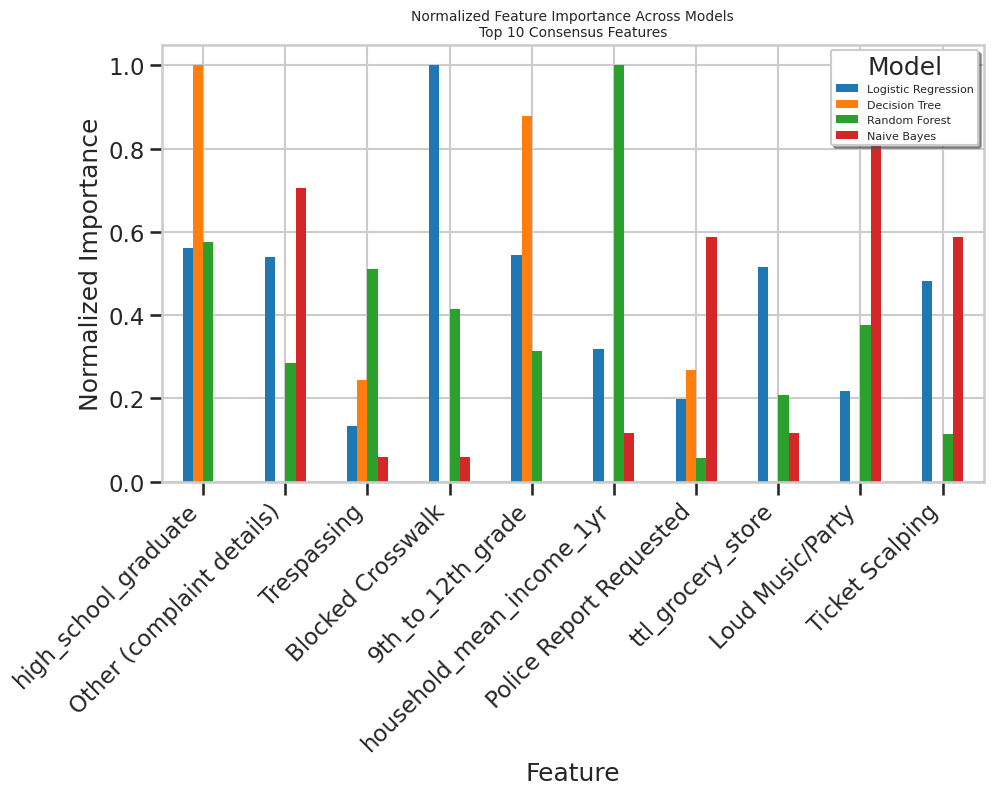

In [105]:
# Plot normalized importance
plt.figure(figsize=(14, 14))
normalized_importance.plot(kind='bar', figsize=(10,8))
plt.rcParams.update({
    'font.size': 8,           # 全局基础字体大小
    'axes.titlesize': 10,      # 标题字体大小
    'axes.labelsize': 10,      # 坐标轴标签字体大小
    'xtick.labelsize': 8,     # X轴刻度字体大小
    'ytick.labelsize': 8,     # Y轴刻度字体大小
    'legend.fontsize': 8      # 图例字体大小
})
plt.title('Normalized Feature Importance Across Models\nTop 10 Consensus Features')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Normalized Importance')
plt.xlabel('Feature')
plt.legend(title='Model', 
           loc='upper right',  # 关键参数：定位到右上角
           bbox_to_anchor=(1, 1),  # 微调位置
           frameon=True,  # 添加边框
           shadow=True,  # 添加阴影
           fancybox=True,fontsize=8) 
plt.tight_layout()
plt.show()

In [106]:
# Create a summary table for the top 10 consensus features
print("\nSummary of Top 10 Consensus Features:")
summary_table = pd.DataFrame(index=top_10_consistent)

for name, importance_df in importance_by_model.items():
    feature_data = importance_df.set_index('Feature').loc[top_10_consistent, 'Importance']
    summary_table[f'{name} Importance'] = feature_data
    summary_table[f'{name} Rank'] = importance_df.set_index('Feature').loc[top_10_consistent, 'Rank']

print(summary_table)


Summary of Top 10 Consensus Features:
                           Logistic Regression Importance  \
high_school_graduate                             0.721212   
Other (complaint details)                        0.695242   
Trespassing                                      0.173183   
Blocked Crosswalk                                1.287143   
9th_to_12th_grade                                0.699660   
household_mean_income_1yr                        0.410180   
Police Report Requested                          0.256963   
ttl_grocery_store                                0.664270   
Loud Music/Party                                 0.281341   
Ticket Scalping                                  0.619434   

                           Logistic Regression Rank  Decision Tree Importance  \
high_school_graduate                           12.0                  0.106194   
Other (complaint details)                      14.0                  0.000000   
Trespassing                                   